In [20]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

In [2]:
# 2. LOAD DATA

df = pd.read_parquet(r"final_features/customer_features_final.parquet")

In [3]:
# 3. INITIAL EXPLORATION

print("============== HEAD ==============")
print(df.head())

print("\n============== SHAPE ==============")
print(df.shape)

print("\n============== NULL VALUES ==============")
print(df.isnull().sum())

============== HEAD ==============
   customer_id municipality risk_rating onboarding_date  age  assets_total  \
0            1     Medellín         low      2024-03-06   20      9,644.53   
1            2      Armenia         low      2019-12-14   62     31,913.51   
2            3     Montería        high      2019-04-10   31     22,262.19   
3            4  Santa Marta      medium      2017-08-30   62     67,375.64   
4            5  Santa Marta         low      2019-04-02   53     27,237.00   

   liabilities_total  monthly_income  monthly_expenses  pep_flag  \
0           4,848.53        5,348.34          4,453.54         0   
1          25,856.24        3,575.39          1,502.09         0   
2           5,126.01        7,904.58          3,826.75         0   
3          16,591.10        2,871.72          2,760.11         0   
4          13,887.45        8,846.98          6,561.25         0   

   tx_count_credit  tx_count_debit  amount_sum_credit  amount_sum_debit  
0            

In [5]:
df.fillna(0, inplace=True)

In [7]:
# 4. NUMERIC VARIABLES

numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ["customer_id", "age", "pep_flag"]
]

print("\n============== NUMERIC VARIABLES ==============")
print(numeric_cols)


============== NUMERIC VARIABLES ==============
['assets_total', 'liabilities_total', 'monthly_income', 'monthly_expenses', 'tx_count_credit', 'tx_count_debit', 'amount_sum_credit', 'amount_sum_debit']


In [8]:
# 5. DESCRIBE NUMERIC VARIABLES

describe_table = df[numeric_cols].describe().T

print("\n============== DESCRIBE TABLE ==============")
print(describe_table)

# Save describe table
describe_table.to_excel("describe_numeric_variables.xlsx")


============== DESCRIBE TABLE ==============
                     count       mean        std      min       25%  \
assets_total      5,000.00 100,012.71 120,816.71 1,226.84 30,979.64   
liabilities_total 5,000.00  51,277.66  74,531.50   565.22 12,553.78   
monthly_income    5,000.00  10,667.82   8,412.43   684.52  5,198.82   
monthly_expenses  5,000.00   7,985.10   6,864.66   297.73  3,620.04   
tx_count_credit   5,000.00       0.15       0.07     0.00      0.08   
tx_count_debit    5,000.00       0.15       0.07     0.00      0.08   
amount_sum_credit 5,000.00 439,136.06 587,747.78     0.00 13,333.33   
amount_sum_debit  5,000.00 695,478.62 776,761.41     0.00 22,500.00   

                         50%        75%          max  
assets_total       59,681.49 119,536.64 1,469,221.14  
liabilities_total  27,121.28  58,441.00   978,710.82  
monthly_income      8,403.05  13,296.85    83,218.97  
monthly_expenses    5,989.42  10,093.79    70,668.56  
tx_count_credit         0.17       0.17

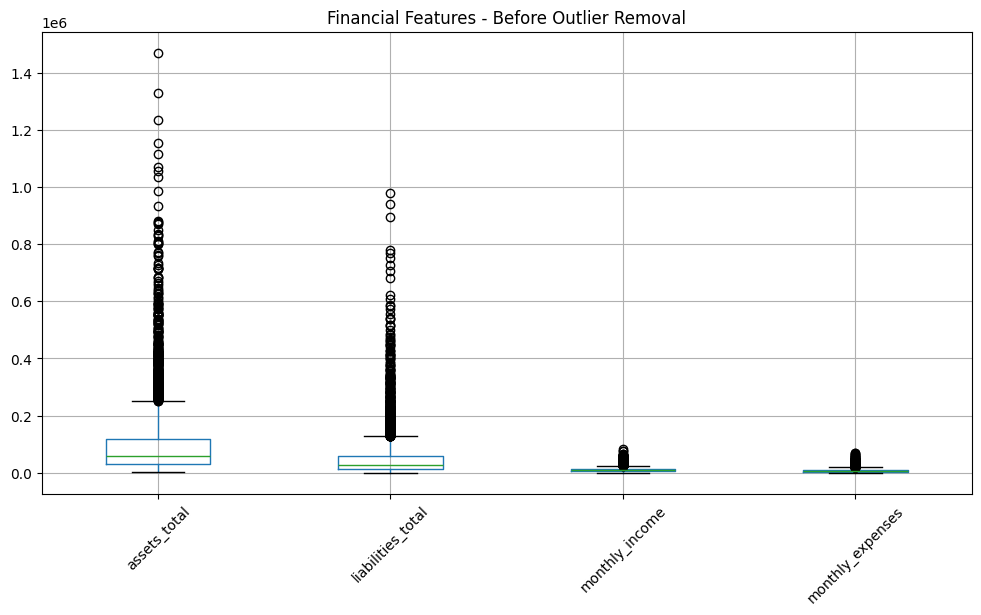

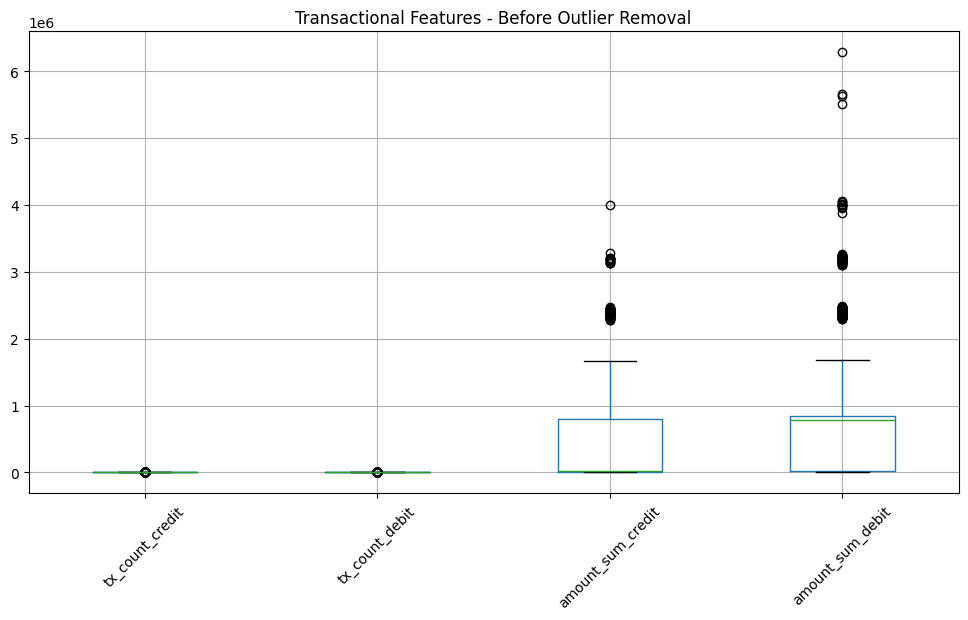

In [9]:
# 6. BOXPLOTS BEFORE OUTLIER REMOVAL

financial_features = [
    "assets_total",
    "liabilities_total",
    "monthly_income",
    "monthly_expenses"
]

transactional_features = [
    "tx_count_credit",
    "tx_count_debit",
    "amount_sum_credit",
    "amount_sum_debit"
]

# ---------- Financial Features ----------

plt.figure(figsize=(12,6))
df[financial_features].boxplot()
plt.title("Financial Features - Before Outlier Removal")
plt.xticks(rotation=45)
plt.show()

# ---------- Transactional Features ----------

plt.figure(figsize=(12,6))
df[transactional_features].boxplot()
plt.title("Transactional Features - Before Outlier Removal")
plt.xticks(rotation=45)
plt.show()

In [10]:
# 7. IQR FUNCTION

def remove_outliers_iqr(dataframe, columns):
    
    df_clean = dataframe.copy()
    outliers_list = []

    for col in columns:

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Detect outliers
        outliers = df_clean[
            (df_clean[col] < lower_bound) |
            (df_clean[col] > upper_bound)
        ]

        if not outliers.empty:
            outliers["outlier_variable"] = col
            outliers_list.append(outliers)

        # Keep non-outliers
        df_clean = df_clean[
            (df_clean[col] >= lower_bound) &
            (df_clean[col] <= upper_bound)
        ]

    # Consolidate outliers
    if len(outliers_list) > 0:
        df_outliers = pd.concat(outliers_list).drop_duplicates()
    else:
        df_outliers = pd.DataFrame()

    return df_clean, df_outliers

In [24]:
# 8. SHAPE BEFORE REMOVING OUTLIERS

shape_before = df.shape[0]

print("\n============== SHAPE BEFORE ==============")
print(shape_before)

# 9. REMOVE OUTLIERS

df_clean, df_outliers = remove_outliers_iqr(df, numeric_cols)

# 10. SHAPE AFTER REMOVING OUTLIERS

shape_after = df_clean.shape[0]

print("\n============== SHAPE AFTER ==============")
print(shape_after)

# 11. PERCENTAGE OF DATA KEPT


percentage_kept = (shape_after / shape_before) * 100

print("\n============== PERCENTAGE KEPT ==============")
print(f"{percentage_kept:.2f}%")

# 12. SAVE OUTLIERS

df_outliers.to_excel(
    "outliers/customer_outliers.xlsx",
    index=False
)

print("\nOutliers saved successfully.")


============== SHAPE BEFORE ==============
5000

============== SHAPE AFTER ==============
3524

============== PERCENTAGE KEPT ==============
70.48%


C:\Users\jason\AppData\Local\Temp\ipykernel_14104\1284710316.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["outlier_variable"] = col
C:\Users\jason\AppData\Local\Temp\ipykernel_14104\1284710316.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["outlier_variable"] = col
C:\Users\jason\AppData\Local\Temp\ipykernel_14104\1284710316.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea


Outliers saved successfully.


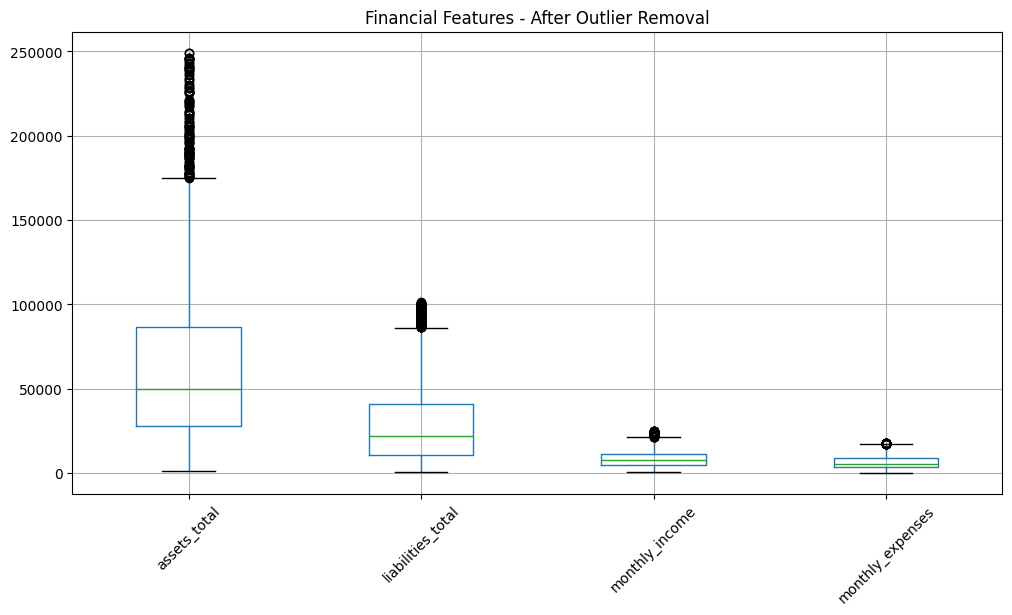

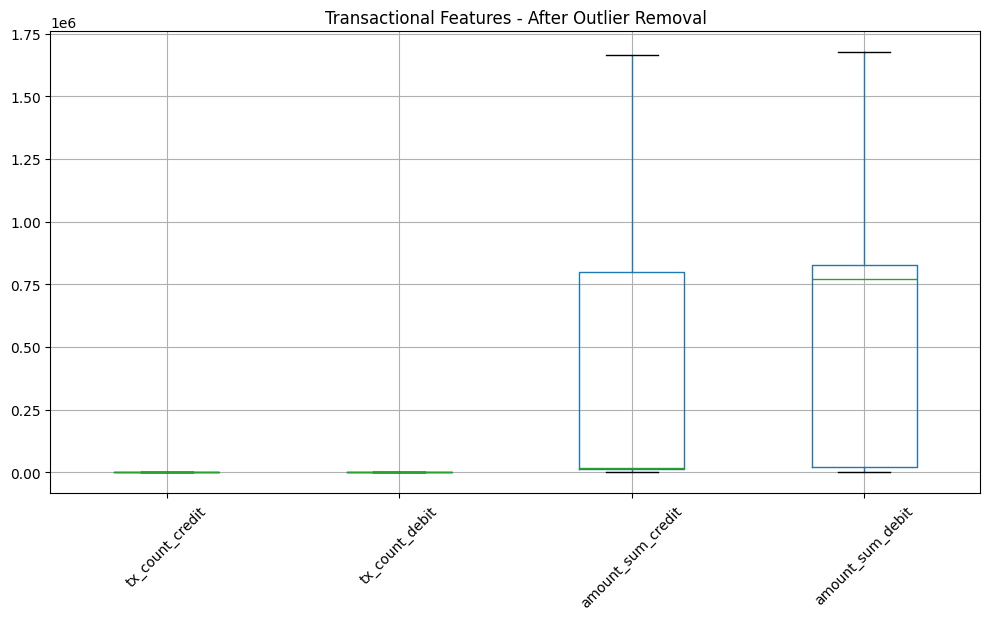

In [12]:
# 13. BOXPLOTS AFTER OUTLIER REMOVAL

# ---------- Financial Features ----------

plt.figure(figsize=(12,6))
df_clean[financial_features].boxplot()
plt.title("Financial Features - After Outlier Removal")
plt.xticks(rotation=45)
plt.show()

# ---------- Transactional Features ----------

plt.figure(figsize=(12,6))
df_clean[transactional_features].boxplot()
plt.title("Transactional Features - After Outlier Removal")
plt.xticks(rotation=45)
plt.show()


============== RISK RATING COUNTS ==============
risk_rating
low       2591
medium     804
high       129
Name: count, dtype: int64


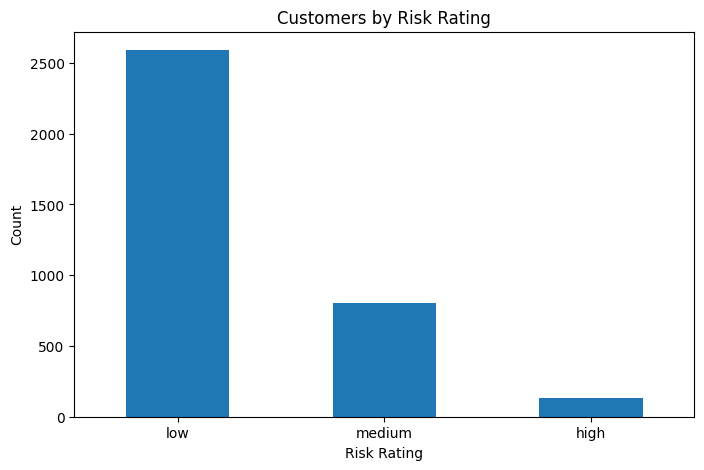

In [13]:
# 14. RISK RATING DISTRIBUTION

risk_counts = df_clean["risk_rating"].value_counts()

print("\n============== RISK RATING COUNTS ==============")
print(risk_counts)

# Histogram / Bar Plot

plt.figure(figsize=(8,5))
risk_counts.plot(kind="bar")

plt.title("Customers by Risk Rating")
plt.xlabel("Risk Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

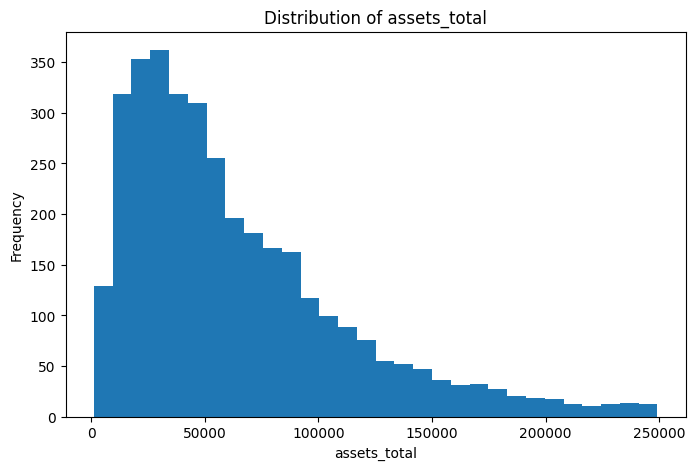

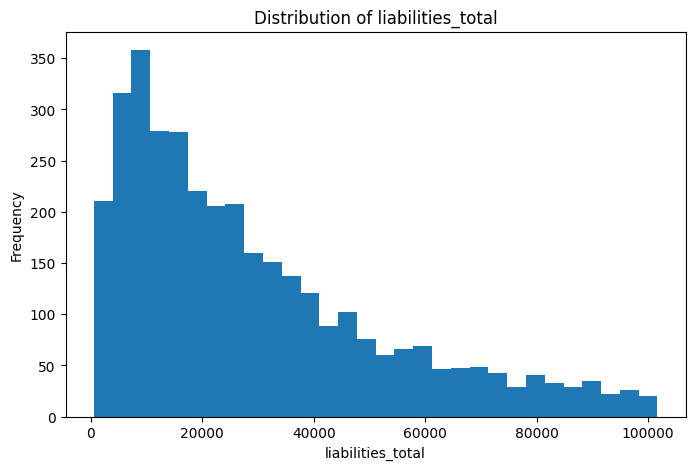

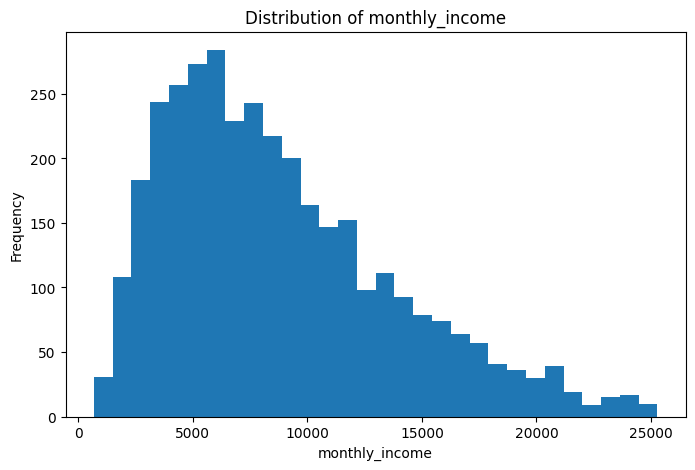

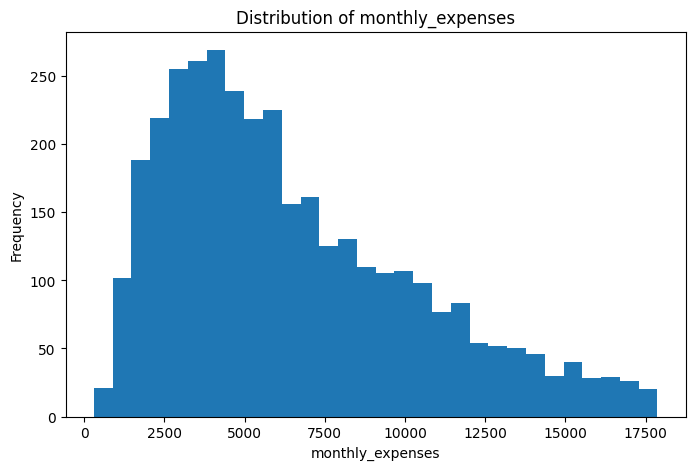

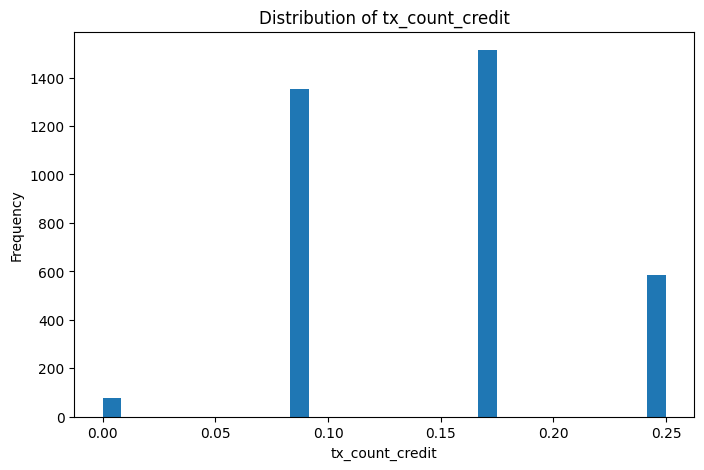

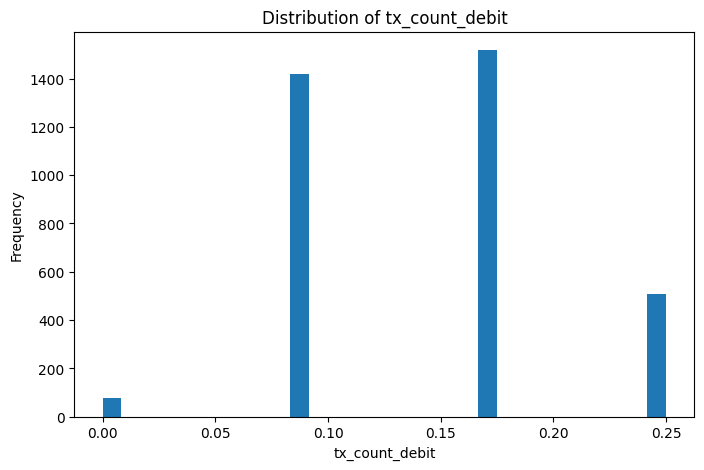

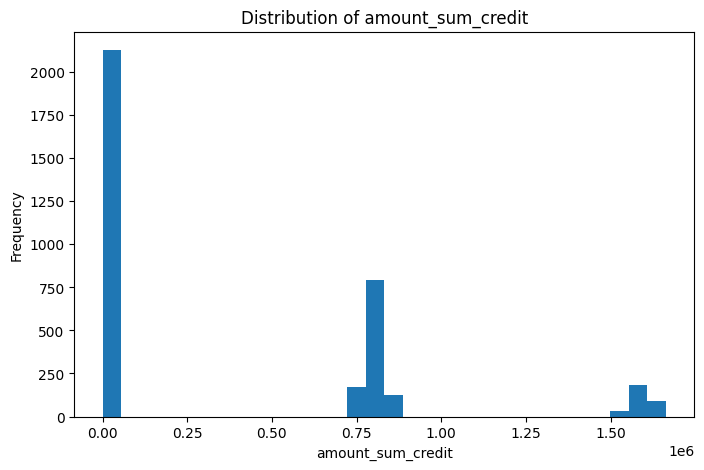

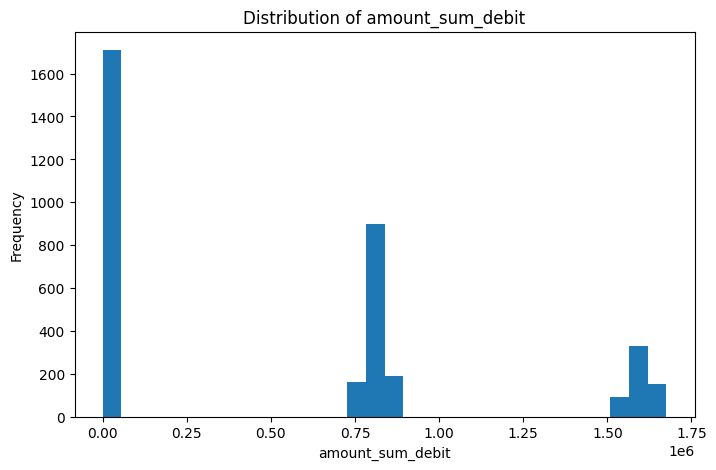

In [14]:
# 15. HISTOGRAMS FOR ALL NUMERIC VARIABLES

for col in numeric_cols:

    plt.figure(figsize=(8,5))

    plt.hist(
        df_clean[col],
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

In [23]:
# 16. TRANSPOSED SUMMARY TABLE

summary_table = df_clean[numeric_cols].describe().T

print("\n============== SUMMARY TABLE ==============")
print(summary_table)

# Optional save
summary_table.to_excel(
    "summary/customer_summary_table.xlsx"
)


============== SUMMARY TABLE ==============
                     count       mean        std      min       25%  \
assets_total      3,524.00  63,620.79  48,227.45 1,226.84 27,808.06   
liabilities_total 3,524.00  29,200.39  23,538.25   565.22 10,648.26   
monthly_income    3,524.00   8,794.66   4,977.07   684.52  4,951.15   
monthly_expenses  3,524.00   6,465.77   3,888.23   297.73  3,425.50   
tx_count_credit   3,524.00       0.14       0.06     0.00      0.08   
tx_count_debit    3,524.00       0.14       0.06     0.00      0.08   
amount_sum_credit 3,524.00 394,439.81 512,822.33     0.00 12,916.67   
amount_sum_debit  3,524.00 554,531.75 581,019.68     0.00 21,250.00   

                         50%        75%          max  
assets_total       49,941.72  86,655.33   249,216.71  
liabilities_total  22,308.81  40,954.89   101,654.19  
monthly_income      7,792.56  11,633.58    25,280.94  
monthly_expenses    5,549.80   8,866.25    17,869.11  
tx_count_credit         0.17       0.17 

In [16]:
# 17. CORRELATION MATRIX (PEARSON)


corr_matrix = df_clean[numeric_cols].corr(method="pearson")

print("\n============== CORRELATION MATRIX ==============")
print(corr_matrix)




============== CORRELATION MATRIX ==============
                   assets_total  liabilities_total  monthly_income  \
assets_total               1.00               0.73            0.01   
liabilities_total          0.73               1.00            0.01   
monthly_income             0.01               0.01            1.00   
monthly_expenses          -0.00               0.01            0.86   
tx_count_credit           -0.04              -0.02            0.01   
tx_count_debit            -0.03              -0.02            0.01   
amount_sum_credit          0.00              -0.00           -0.03   
amount_sum_debit          -0.03              -0.02           -0.01   

                   monthly_expenses  tx_count_credit  tx_count_debit  \
assets_total                  -0.00            -0.04           -0.03   
liabilities_total              0.01            -0.02           -0.02   
monthly_income                 0.86             0.01            0.01   
monthly_expenses               

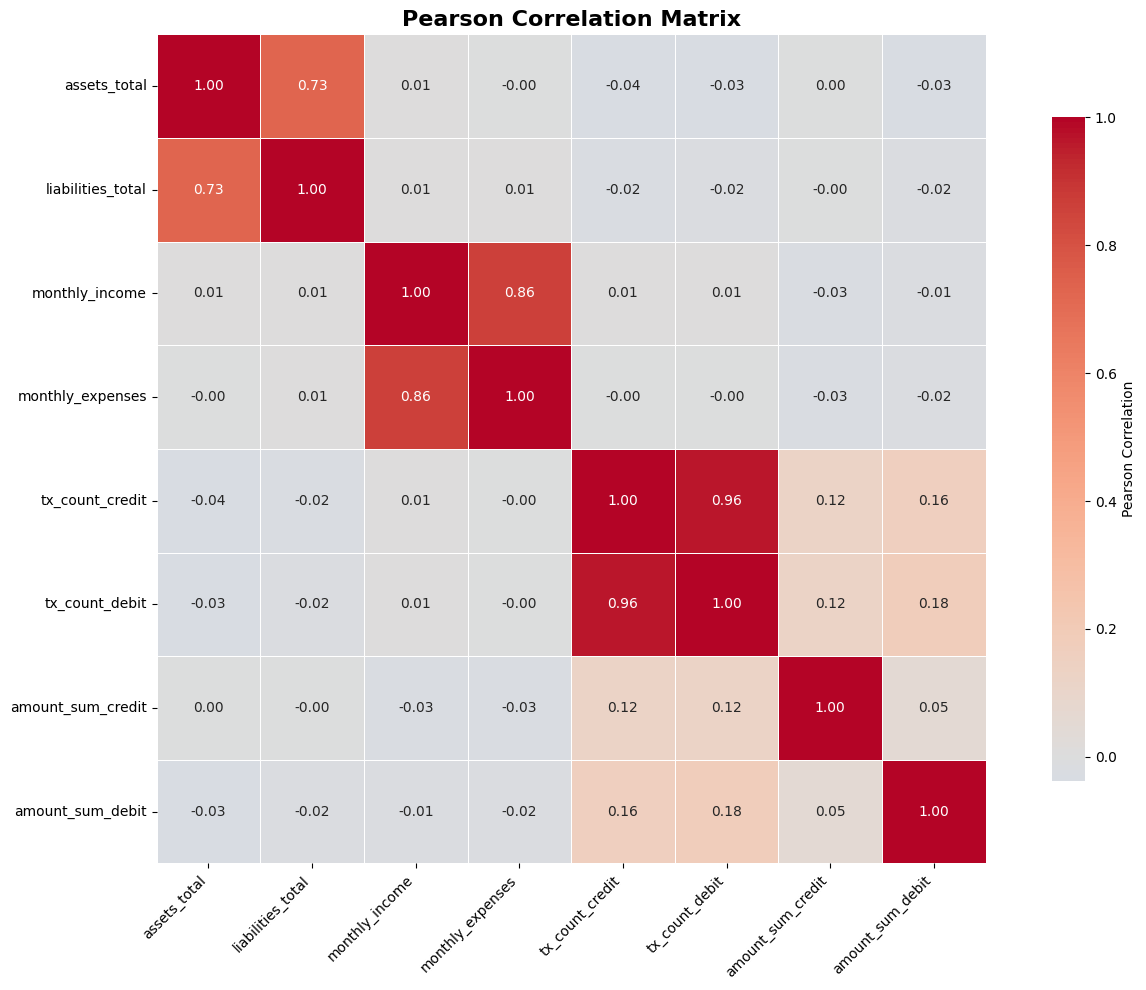

In [21]:
# 18. CORRELATION HEATMAP

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    
    annot=True,          # Show correlation values
    fmt=".2f",           # 2 decimal places
    
    cmap="coolwarm",     # Color palette
    
    center=0,            # Center colors at zero
    
    linewidths=0.5,      # Add separation lines
    
    square=True,         # Square cells
    
    cbar_kws={
        "shrink": 0.8,
        "label": "Pearson Correlation"
    }
)

plt.title(
    "Pearson Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [22]:
# 19. SAVE CLEAN DATASET

df_clean.to_parquet(
    "clean_datasets/customer_features_clean.parquet",
    index=False
)

print("\nClean dataset saved successfully.")


Clean dataset saved successfully.
